# 1. Імпорт

In [153]:
import warnings
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.metrics import (mean_absolute_error,mean_absolute_percentage_error)
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler, PolynomialFeatures

# 2. Завантажте  набір

In [159]:
california_housing = fetch_california_housing(as_frame=True)

data = california_housing['frame']
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


# 3.1. Очистка від викидів

In [162]:
from scipy.stats import zscore

outlier_columns = [
    "AveRooms",
    "AveBedrms",
    "AveOccup",
    "Population"
]

# Робимо копію даних
df_copy = data.copy()
# Рахуємо z-score для колонок
z_scores = df_copy[outlier_columns].apply(zscore)
# Беремо модуль, бо аномалії можуть бути і дуже великими, і дуже малими
z_scores_abs = np.abs(z_scores)
# Визначаємо рядки, де хоча б в одній колонці z-score > 3
outliers_mask = (z_scores_abs > 3).any(axis=1)
print("Кількість рядків з викидами:", outliers_mask.sum())

Кількість рядків з викидами: 505


In [163]:
# Видаляємо рядки з викидами
df_cleaned = df_copy[~outliers_mask].copy()
print("Розмір датасету після очищення:", df_cleaned.shape)

Розмір датасету після очищення: (20135, 9)


# 3.2. Видалення однієї сильно корельованої ознаки

<Axes: >

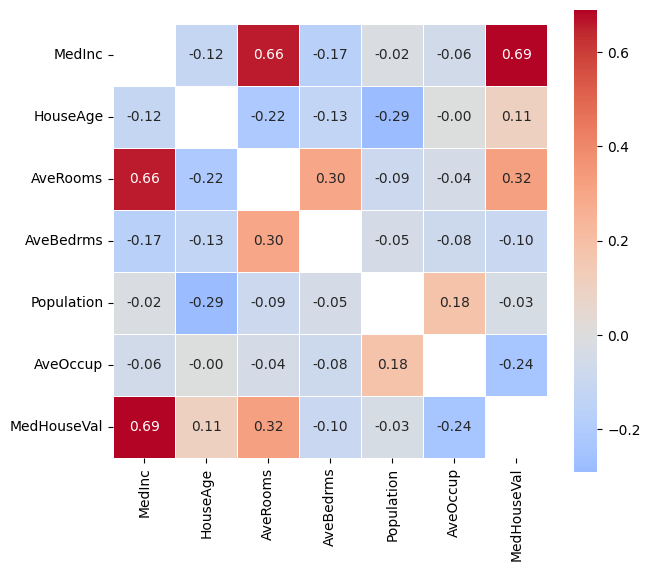

In [164]:
columns_drop = ['Longitude', 'Latitude']
subset = df_cleaned.drop(columns=columns_drop)

corr_mtx = subset.corr()

mask_mtx = np.zeros_like(corr_mtx)
np.fill_diagonal(mask_mtx, 1)

fig, ax = plt.subplots(figsize=(7, 6))

sns.heatmap(subset.corr(),
            cmap='coolwarm',
            center=0,
            annot=True,
            fmt='.2f',
            linewidth=0.5,
            square=True,
            mask=mask_mtx,
            ax=ax)

**Висновок:**
Сильної кореляції (> 0.85) між парами ознак не виявлено після видалення викідів; немає підстави для видалення однієї з ознак.

In [139]:
# залежність колонок визначено на попередньому кроці
# df_cleaned = df_cleaned.drop(columns=["AveRooms"])

# 4. Розбиття на навчальну і тестову вибірки

In [165]:
X = df_cleaned.drop(columns='MedHouseVal')
y = df_cleaned["MedHouseVal"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42)

print("Розмір X_train:", X_train.shape)
print("Розмір X_test:", X_test.shape)

Розмір X_train: (16108, 8)
Розмір X_test: (4027, 8)


# 5. Нормалізація ознак

In [166]:
scaler = StandardScaler().set_output(transform='pandas').fit(X_train)

X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 6. Побудова моделі LinearRegression

In [167]:
model = LinearRegression().fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)

ymin, ymax = y_train.agg(['min', 'max']).values

y_pred = pd.Series(y_pred, index=X_test_scaled.index).clip(ymin, ymax)
# Оцінювання точності моделі
r_sq = model.score(X_train_scaled, y_train)
mae_upd = mean_absolute_error(y_test, y_pred)
mape_upd = mean_absolute_percentage_error(y_test, y_pred)

print(f'R2: {r_sq:.2f} | MAE: {mae_upd:.2f} | MAPE: {mape_upd:.2f}')

R2: 0.65 | MAE: 0.49 | MAPE: 0.29


Показники до очищення данних:

R2: 0.61 | MAE: 0.52 | MAPE: 0.31

Аналіз:
R² збільшився з 0.61 до 0.65 (+0.04 або приблизно +6.6%). Модель почала краще пояснювати залежність між ознаками та вартістю житла.
MAE зменшився з 0.52 до 0.49, тобто середня абсолютна помилка прогнозу стала меншою.
MAPE зменшився з 0.31 до 0.29, отже відносна похибка прогнозування також знизилася.


Висновок для Linear Regression:
Очищення від викидів у колонках AveRooms, AveBedrms, AveOccup та Population суттєво покращило якість лінійної моделі. Видалення аномальних спостережень дозволило моделі краще виявляти лінійні залежності в даних та підвищити точність прогнозування.

# 7. Поліноміальна регресія

In [168]:
poly = PolynomialFeatures(2).set_output(transform='pandas')

Xtr = poly.fit_transform(X_train_scaled)
Xts = poly.transform(X_test_scaled)

model_upd = LinearRegression().fit(Xtr, y_train)
y_pred_upd = model_upd.predict(Xts)
y_pred_upd = pd.Series(y_pred_upd, index=Xts.index).clip(ymin, ymax)
# Оцінювання точності моделі
r_sq_upd = model_upd.score(Xtr, y_train)
mae_upd = mean_absolute_error(y_test, y_pred_upd)
mape_upd = mean_absolute_percentage_error(y_test, y_pred_upd)

print(f'R2: {r_sq_upd:.2f} | MAE: {mae_upd:.2f} | MAPE: {mape_upd:.2f}')

R2: 0.71 | MAE: 0.44 | MAPE: 0.25


Показники до очищення данних:

R2: 0.69 | MAE: 0.46 | MAPE: 0.27

Аналіз:
R² збільшився з 0.69 до 0.71 (+0.02 або приблизно +2.9%).
MAE зменшився з 0.46 до 0.44.
MAPE зменшився з 0.27 до 0.25.


Висновок для поліноміальної регресії:
Поліноміальна регресія також отримала покращення після очищення даних. Оскільки ця модель краще враховує нелінійні залежності між ознаками, вона вже до очищення демонструвала вищу точність. Проте видалення викидів дозволило ще більше зменшити похибки прогнозування та підвищити якість моделі.

# Висновок:

Очищення набору даних від викидів методом Z-score для ознак AveRooms, AveBedrms, AveOccup та Population позитивно вплинуло на результати обох моделей. Після видалення аномальних значень спостерігається збільшення коефіцієнта детермінації R² та зменшення показників MAE і MAPE, що свідчить про підвищення точності прогнозування.

Найбільше покращення отримала модель лінійної регресії, оскільки вона більш чутлива до наявності викидів у даних. Поліноміальна регресія також покращила свої показники та залишилася найточнішою моделлю серед розглянутих.

Найкращий результат було отримано для поліноміальної регресії після очищення даних:

      R² = 0.71
      MAE = 0.44
      MAPE = 0.25

Отже, проведена попередня обробка даних підтвердила свою ефективність, а використання поліноміальної регресії дозволило досягти найвищої якості прогнозування вартості житла в наборі даних California Housing.

Експеримент показав, що очищення від викидів повинно виконуватися вибірково. Видалення аномалій лише в ознаках AveRooms, AveBedrms, AveOccup та Population дозволило покращити якість моделей, оскільки саме ці ознаки містять найбільшу кількість нереалістичних значень. Натомість очищення всіх колонок призводить до втрати корисної інформації, зокрема про рівень доходу населення, географічне розташування та екстремальні значення цільової змінної. Через це якість моделей покращується менше або навіть може погіршуватися.

Отримані результати підтверджують доцільність цільового очищення лише тих ознак, для яких наявність аномалій була попередньо підтверджена під час аналізу даних.